In [1]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

env: CUDA_VISIBLE_DEVICES=1


In [2]:
from lm_saes import SparseAutoEncoder, LowRankSparseAttention
from transformer_lens import HookedTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig
from IPython.display import SVG, display

import torch
import chess

import json
from pathlib import Path
import os
import sys
from typing import Optional, Dict, Any, Tuple, List, Set

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))


from datasets import load_from_disk
import random


import numpy as np
from tqdm.auto import tqdm

from src.chess_utils import get_feature_vector, get_pos_from_square, get_piece_type_pos, feature_frequency_with_piece_type

In [3]:
model_name = 'lc0/BT4-1024x15x32h'
model = HookedTransformer.from_pretrained_no_processing(
    model_name,
    dtype=torch.float32,
).eval()

transcoders = {
    layer: SparseAutoEncoder.from_pretrained(
        f'/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/result_BT4/tc/k_30_e_16/L{layer}',
        dtype=torch.float32,
        device='cuda',
    )
    for layer in range(15)
}

lorsas = [
    LowRankSparseAttention.from_pretrained(
        f'/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/result_BT4/lorsa/k_30_e_16/L{layer}',
        dtype=torch.float32,
        device='cuda',
    )
    for layer in range(15)
]

state_dict keys: dict_keys(['embed.ma_gating_mul', 'embed.ma_gating_add', 'embed.ffn_alpha', 'embed.embedding_preprocess.weight', 'embed.embedding_preprocess.bias', 'embed.main_linear.weight', 'embed.main_linear.bias', 'embed.ffn_dense1.weight', 'embed.ffn_dense1.bias', 'embed.ffn_dense2.weight', 'embed.ffn_dense2.bias', 'embed.ln.weight', 'embed.ln.bias', 'embed.ln2.weight', 'embed.ln2.bias', 'blocks.0.alpha_input', 'blocks.0.alpha_out1', 'blocks.0.mha.qk_scale', 'blocks.0.mha.q_proj.weight', 'blocks.0.mha.q_proj.bias', 'blocks.0.mha.k_proj.weight', 'blocks.0.mha.k_proj.bias', 'blocks.0.mha.v_proj.weight', 'blocks.0.mha.v_proj.bias', 'blocks.0.mha.out_proj.weight', 'blocks.0.mha.out_proj.bias', 'blocks.0.mha.smolgen.compress.weight', 'blocks.0.mha.smolgen.dense1.weight', 'blocks.0.mha.smolgen.dense1.bias', 'blocks.0.mha.smolgen.ln1.weight', 'blocks.0.mha.smolgen.ln1.bias', 'blocks.0.mha.smolgen.dense2.weight', 'blocks.0.mha.smolgen.dense2.bias', 'blocks.0.mha.smolgen.ln2.weight', 'blo

[fill_missing_keys] missing_keys: {'pos_embed.W_pos', 'policy_head.promotion_weight'}
Loaded pretrained model lc0/BT4-1024x15x32h into HookedTransformer


/inspire/hdd/global_user/hezhengfu-240208120186/rlin_projects/rlin_projects/chess-SAEs-N/.venv/lib/python3.11/site-packages/torch/distributed/checkpoint/state_dict_loader.py:153: UserWarning: torch.distributed is disabled, unavailable or uninitialized, assuming the intent is to load in a single process.
  warnings.warn(


In [4]:
dataset_path = "/inspire/hdd/global_user/hezhengfu-240208120186/data/rlin_data/Chess/chess_master_data"

dataset = load_from_disk(dataset_path)

dataset_size = len(dataset)
print(f"length of dataset:{dataset_size}")

random_indices = random.sample(range(dataset_size), min(500, dataset_size))
random_data = [dataset[i]['fen'] for i in random_indices]

for i, item in enumerate(random_data[:5]):
    print(f"Sample {i+1}: {item}")
    
print(f'{len(random_data) = }')

length of dataset:51541318
Sample 1: 8/p3kp1p/1p2p3/2p5/2P1nPN1/3KP1rP/PP6/4R3 b - - 0 32
Sample 2: 1r1r2Bk/4q1nP/3p1b1Q/R3p1p1/1p2P3/1P3b2/PNP5/2K1R3 b - - 0 41
Sample 3: r3k2r/ppqbn1pp/2n1p2P/3pPp2/2pP4/P1P2NB1/2P1BPP1/R2QR1K1 b kq - 0 16
Sample 4: b1rr1nk1/2b2ppp/p3p2q/3n4/PpNPN3/1P3BP1/1B2QP1P/2R1R1K1 w - - 7 23
Sample 5: 2rq1rk1/1p1bbp1p/p1nBp1p1/7n/2B1N3/P1N1P3/1PQ2PPP/3R1RK1 b - - 3 16
len(random_data) = 500


In [5]:
# 己方王的周围8格，如果在边上则保证不超出棋盘

feature = (1, 3938, 'lorsa')

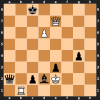

King surrounding squares: [9, 10, 11, 1, 3]


In [6]:
def get_king_surrounding_squares(fen: str) -> list[int]:
    """获取己方王周围的8格位置（如果在边上则保证不超出棋盘）。
    
    Args:
        fen: FEN字符串
    
    Returns:
        己方王周围的8格位置列表（已翻转，适用于模型输入）
    """
    board = chess.Board(fen)
    side_to_move = board.turn
    
    king_square = board.king(side_to_move)
    if king_square is None:
        return []
    
    king_file = chess.square_file(king_square)
    king_rank = chess.square_rank(king_square)
    
    surrounding_squares = []
    # 检查周围8个方向：上下左右和对角线
    for dr in [-1, 0, 1]:
        for df in [-1, 0, 1]:
            if dr == 0 and df == 0:
                continue  # 跳过王自己的位置
            
            new_rank = king_rank + dr
            new_file = king_file + df
            
            # 检查是否在棋盘范围内 (0-7)
            if 0 <= new_rank < 8 and 0 <= new_file < 8:
                surrounding_squares.append(chess.square(new_file, new_rank))
    
    if not surrounding_squares:
        return []
    
    # 如果是黑方，需要翻转坐标
    if board.turn == chess.BLACK:
        flipped = []
        for sq in surrounding_squares:
            file_idx = chess.square_file(sq)
            rank_idx = chess.square_rank(sq)
            flipped.append(chess.square(file_idx, 7 - rank_idx))
        return flipped
    
    return surrounding_squares

fen_test = "2k5/4Q3/3P4/8/6p1/4p3/q1pbK3/1R6 b - - 0 32"
board = chess.Board(fen_test)
svg_board = chess.svg.board(board=board, size=100)
display(SVG(svg_board))
print("King surrounding squares:", get_king_surrounding_squares(fen_test))

In [7]:
def compute_accuracy_for_feature(fen_list: list[str], layer: int, feature_id: int, feature_type: str) -> float:
    """计算指定feature对"己方王周围8格"的accuracy。
    
    Args:
        fen_list: FEN字符串列表
        layer: layer索引
        feature_id: feature索引
        feature_type: feature类型 ("transcoder" 或 "lorsa")
    
    Returns:
        accuracy值（0-1之间）
    """
    device = model.cfg.device
    
    total_active = 0
    active_in_surrounding = 0
    
    for fen in tqdm(fen_list, desc="Computing accuracy"):
        try:
            pos_list = get_king_surrounding_squares(fen)
            if not pos_list:
                continue
            
            pos_mask = torch.zeros(64, dtype=torch.bool, device=device)
            pos_mask[pos_list] = True
            
            # 一次 forward
            _, cache = model.run_with_cache(fen, prepend_bos=False)
            
            if feature_type == 'transcoder':
                hook_name = f'blocks.{layer}.resid_mid_after_ln'
                if hook_name not in cache:
                    continue
                sae = transcoders[layer]
                acts = sae.encode(cache[hook_name])
            else:
                hook_name = f'blocks.{layer}.hook_attn_in'
                if hook_name not in cache:
                    continue
                sae = lorsas[layer]
                acts = sae.encode(cache[hook_name])
            
            acts_all = acts[0] if acts.dim() == 3 else acts  # [seq, d_feat]
            
            seq_len = acts_all.shape[0]
            piece_mask = pos_mask[:seq_len]
            
            feature_activations = acts_all[:, feature_id]  # [seq]
            active = feature_activations > 0
            
            active_in_surrounding_count = (active & piece_mask).sum().item()
            total_active_count = active.sum().item()
            
            active_in_surrounding += active_in_surrounding_count
            total_active += total_active_count
        except Exception as e:
            print(f"Error processing FEN: {e}")
            continue
    
    # Accuracy = 当feature激活时，有多少比例是在"王周围8格"的位置
    accuracy = active_in_surrounding / total_active if total_active > 0 else 0.0
    
    return accuracy

layer, feature_id, feature_type = feature
print(f"计算feature (layer={layer}, feature_id={feature_id}, type={feature_type}) 对'己方王周围8格'的accuracy...")
accuracy = compute_accuracy_for_feature(random_data, layer, feature_id, feature_type)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"说明: 当feature激活时，有 {accuracy*100:.2f}% 的激活发生在己方王周围的8格位置")

计算feature (layer=1, feature_id=3938, type=lorsa) 对'己方王周围8格'的accuracy...


Computing accuracy:   0%|          | 0/500 [00:00<?, ?it/s]


Accuracy: 0.9978 (99.78%)
说明: 当feature激活时，有 99.78% 的激活发生在己方王周围的8格位置
